# **Pretraining on unlabeled data**
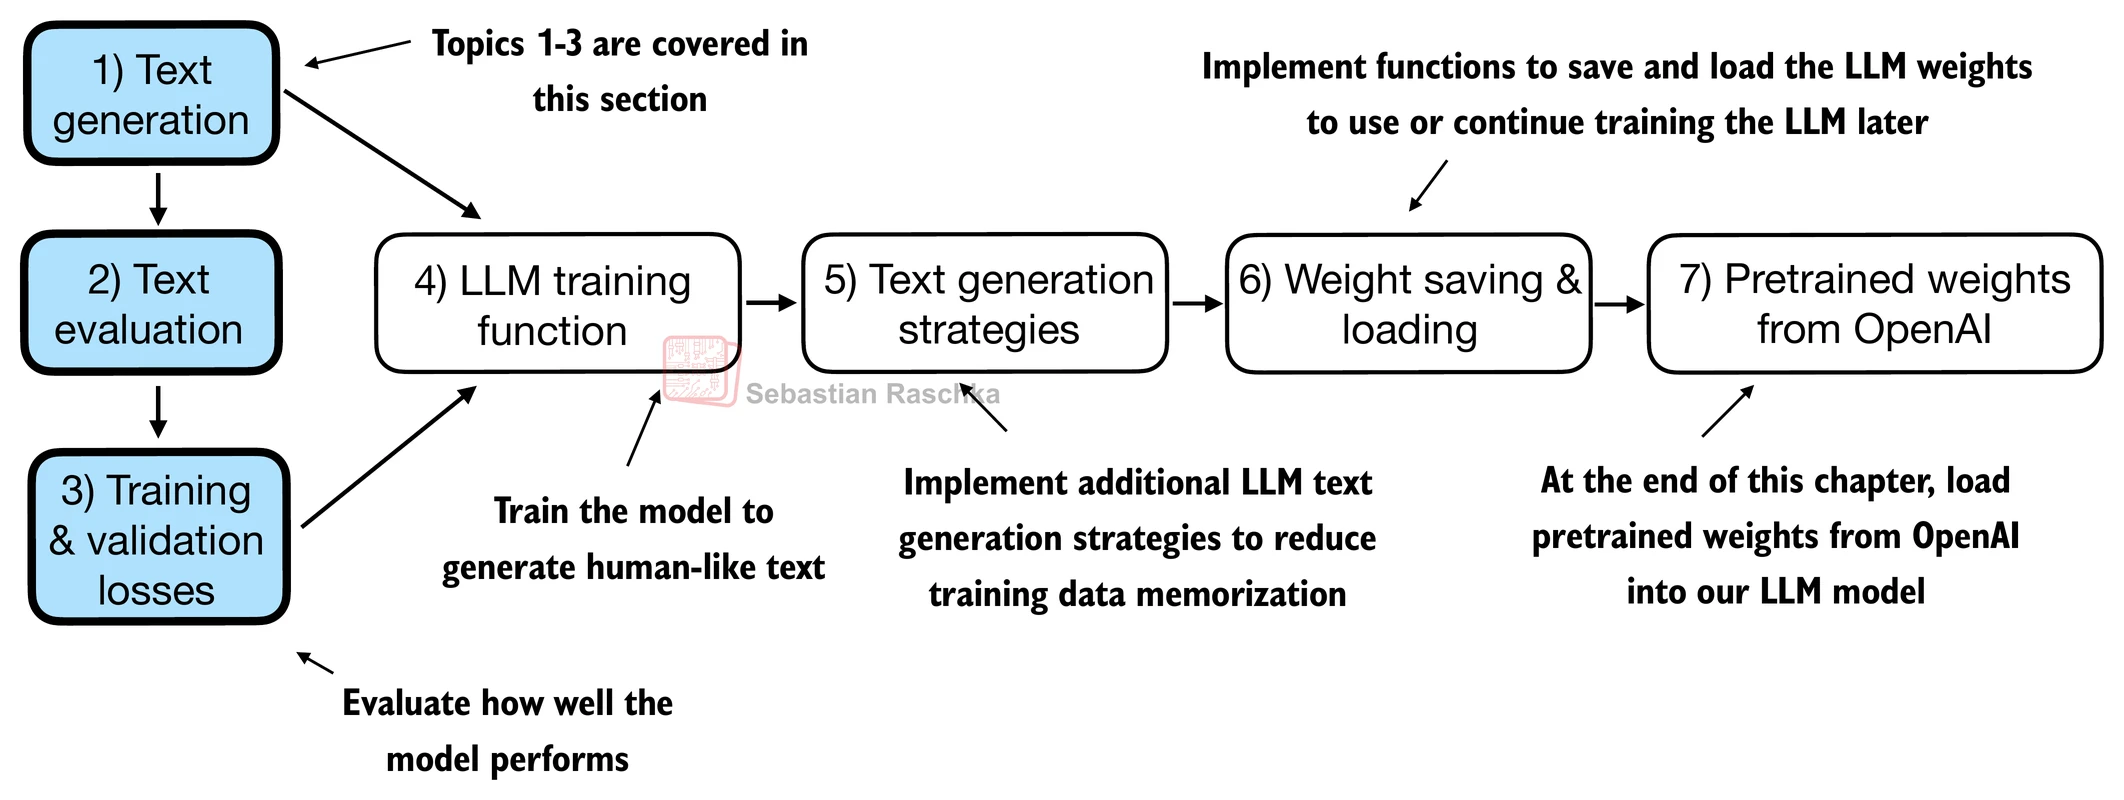

## **Eval generative text models**

#### Generate text using GPT(ch 4)

In [ ]:
import sys
import os

sys.path.append('../GPT_model')

#ch 4 GPT model
from GPT_Model_architecture_class import GPTModel

In [ ]:
import torch

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256, # reduced from 1024 to 256 for faster training
    "emb_dim": 768,
    "num_heads": 12,
    "num_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

reminder of how text is generated and converted between token and text
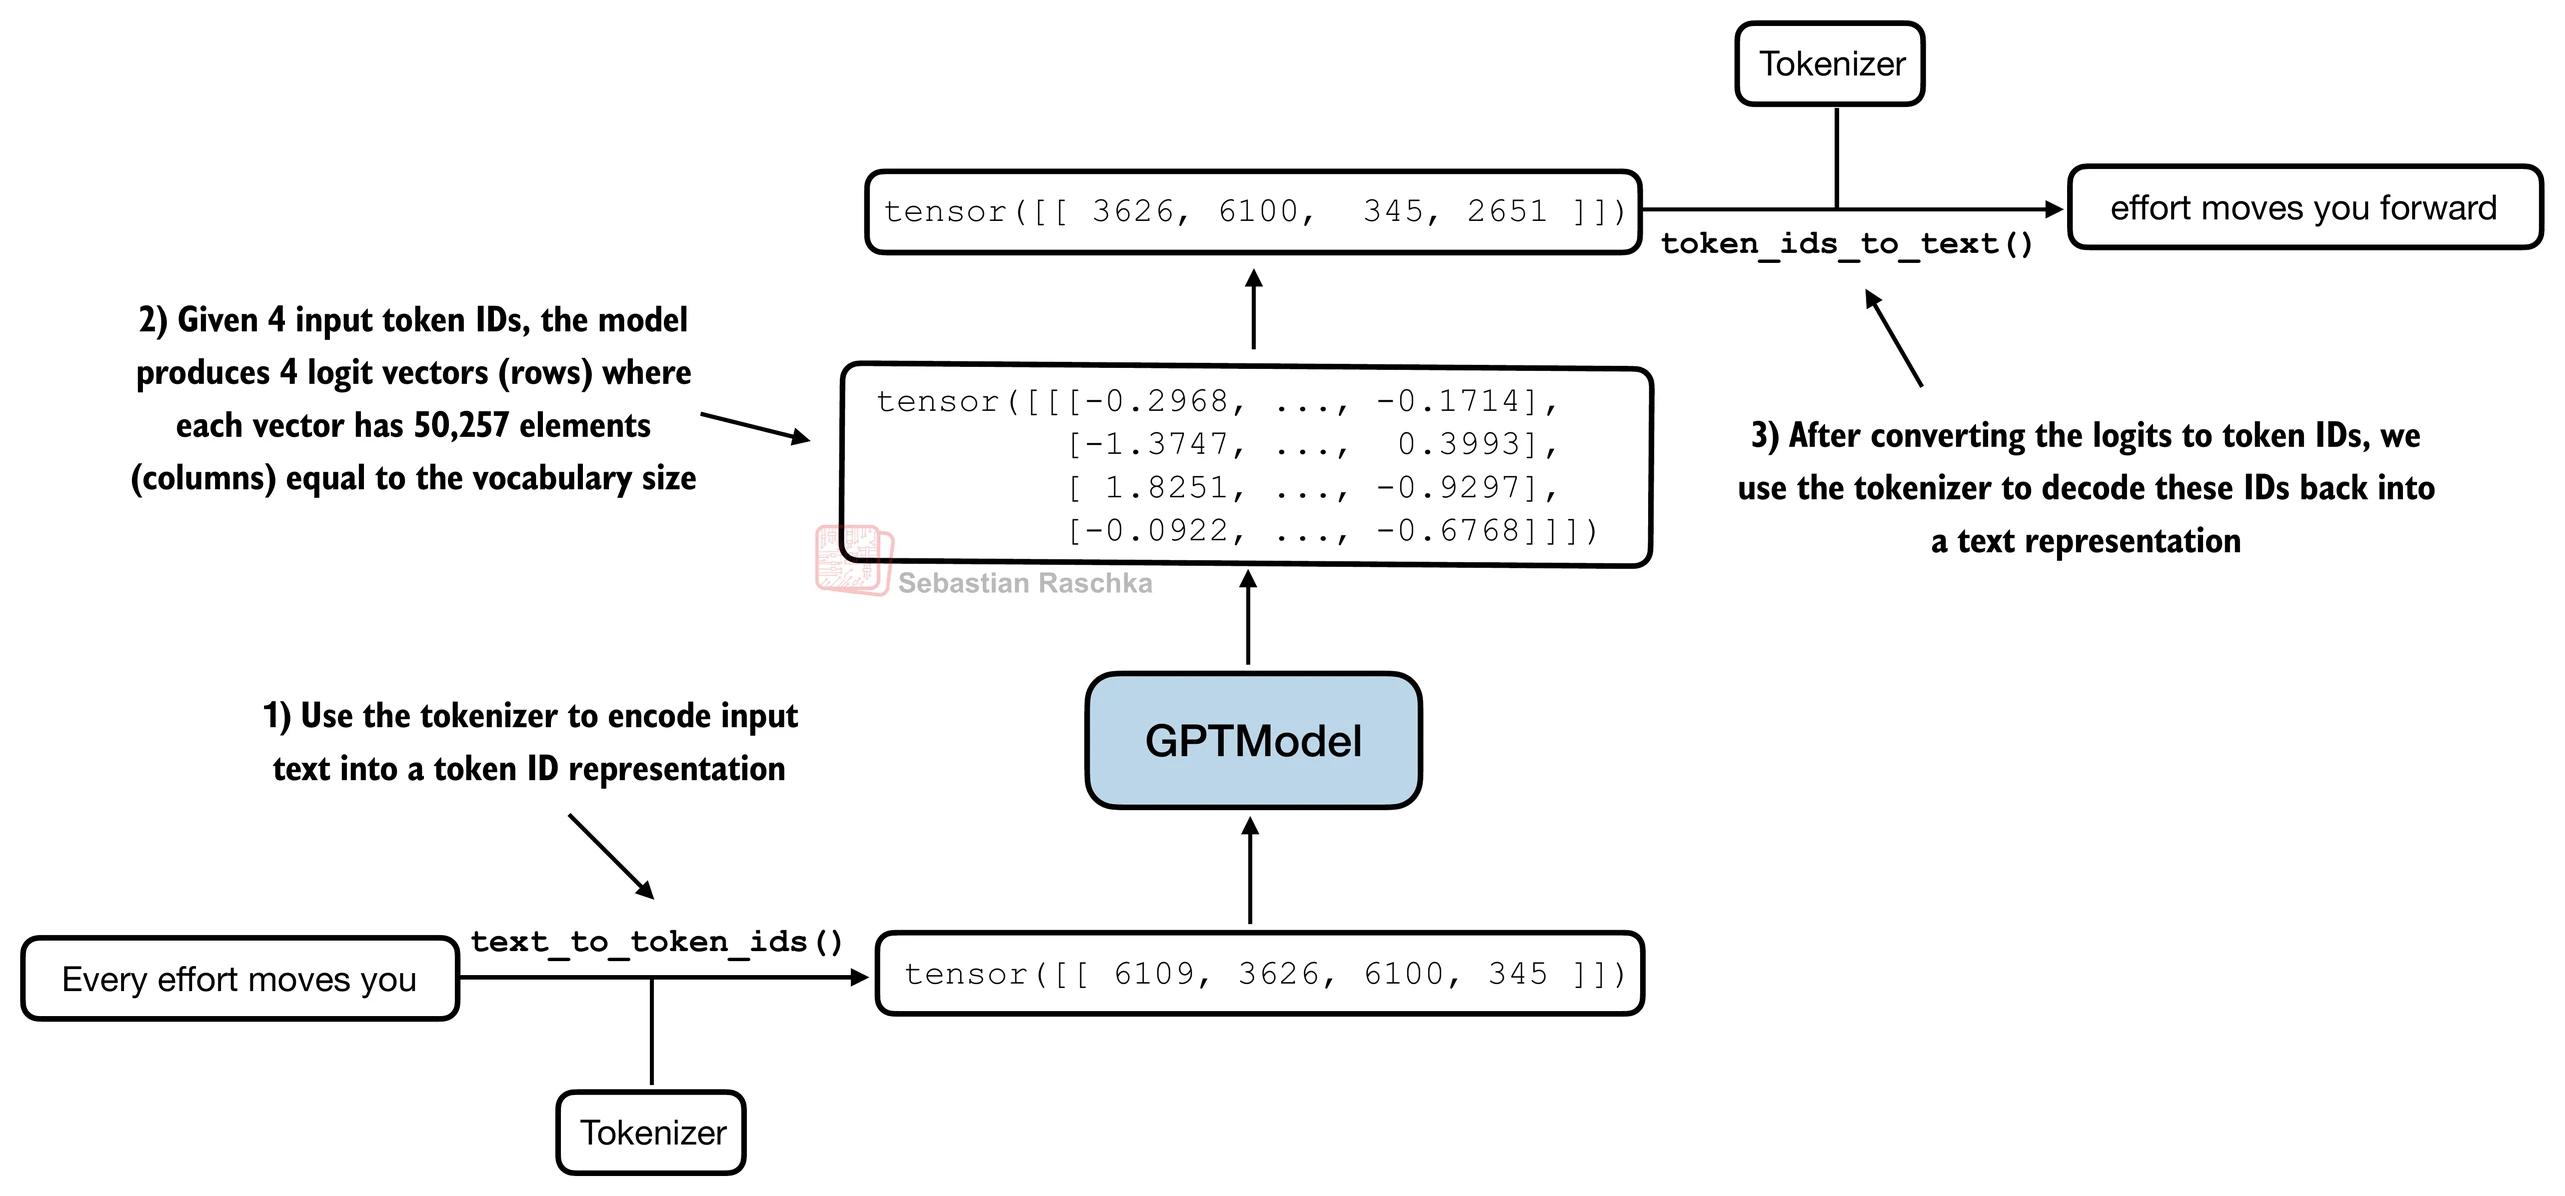

In [ ]:
import tiktoken
from GPT_Model_architecture_class import generate_text_simple

def text_to_token_ids (text, tokenizer):
    encoded = tokenizer.encode (text, allowed_special = {'<|endoftext|>'})

    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension

    return encoded_tensor

def token_ids_to_text (token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    text = tokenizer.decode(flat.tolist()) #convert tensor to list of ints 
    return text


start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context, tokenizer),
    max_new_tokens= 10, #loop repeats 10 times generating 10 new tokens 
    context_size = GPT_CONFIG_124M['context_length']
)

print("Output text: ", token_ids_to_text(token_ids, tokenizer))
#Output is gibberish because model is untrained 

Output text:  Every effort moves you rentingetic wasnم refres RexMeCHicular stren


#### Calculating text generation loss

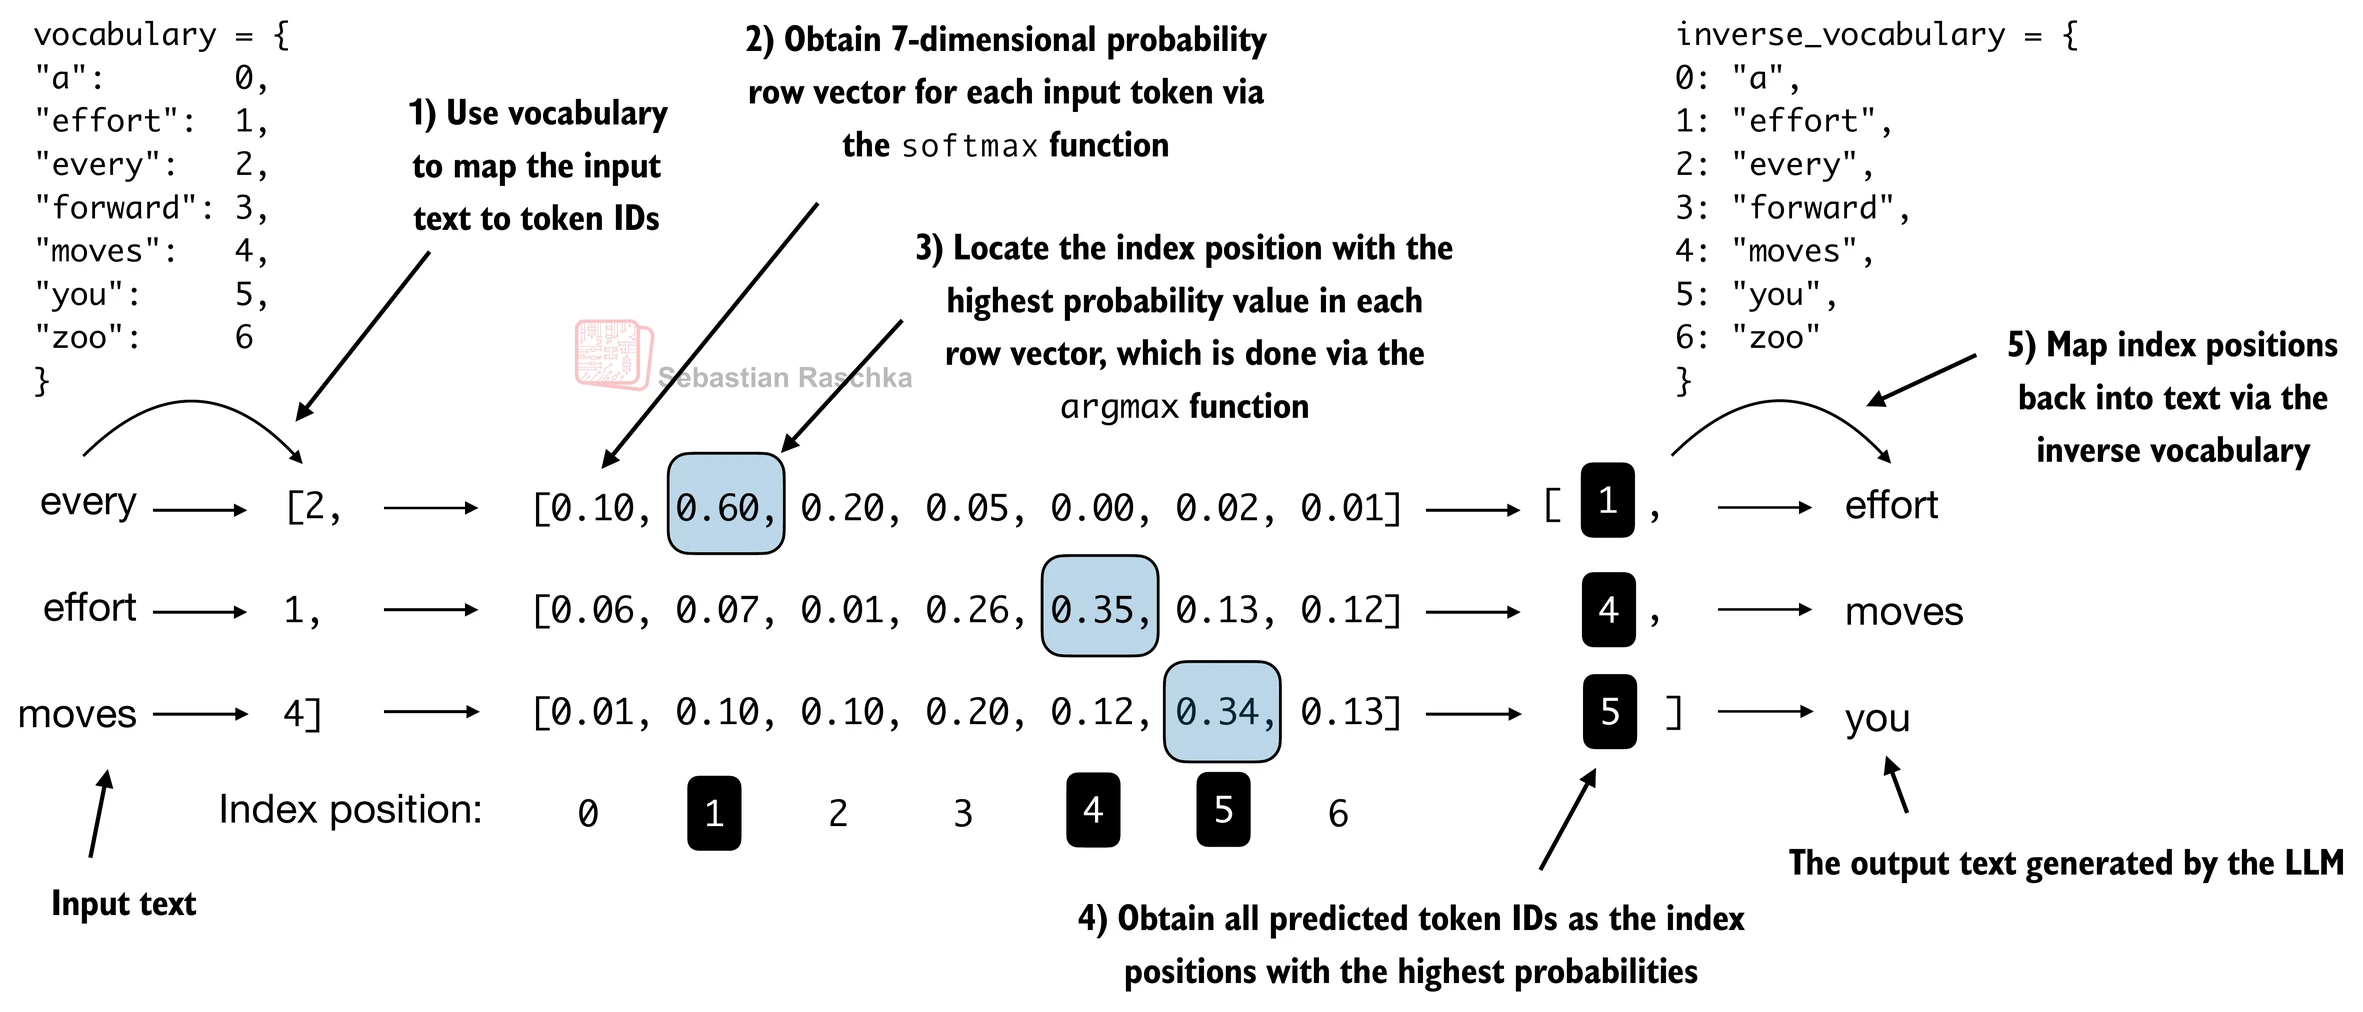
probability scores for each token in the vocab. The index position of the highest probability is the most likely next token ID. This is selected and mapped back to vocab to convert to text. 

In [ ]:
#### STEP 1: tokenize data ####

#tokenized inputs for 2 batches
inputs = torch.tensor ([
    [16833, 3626, 6100], #["Every", "effort", "moves"]
    [40, 1107, 588] #["I", "really", "like"]
])

#tokenized targets for 2 batches
targets = torch.tensor([
    [3626, 6100, 345], #["effort", "moves", "you"]
    [1107, 588, 11311] #["really", "like", "chocolate"]
])


probas shape:  torch.Size([2, 3, 50257])


In [ ]:
#### STEP 2: Probabilies of each token in vocab ####

with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)
print("probas shape: ", probas.shape) # (batch_size, seq_length, vocab_size)

In [ ]:
#### STEP 3/4: locate token with highest probas ####

token_ids = torch.argmax(probas, dim = -1, keepdim = True)
print("Token IDS:\n ", token_ids)

Token IDS:
  tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [9]:
#### STEP 5: convert token ID back to text ####

print("Targets batch 1: ", token_ids_to_text(targets[0], tokenizer))
print("Predicted batch 1: ", token_ids_to_text(token_ids[0].flatten(), tokenizer))

Targets batch 1:   effort moves you
Predicted batch 1:   Armed heNetflix


For evaluating the text we need to need a mathematical metric to calculate how *wrong* it is.  We need to increase the probability of the correct target token ids makeing the predicted == target
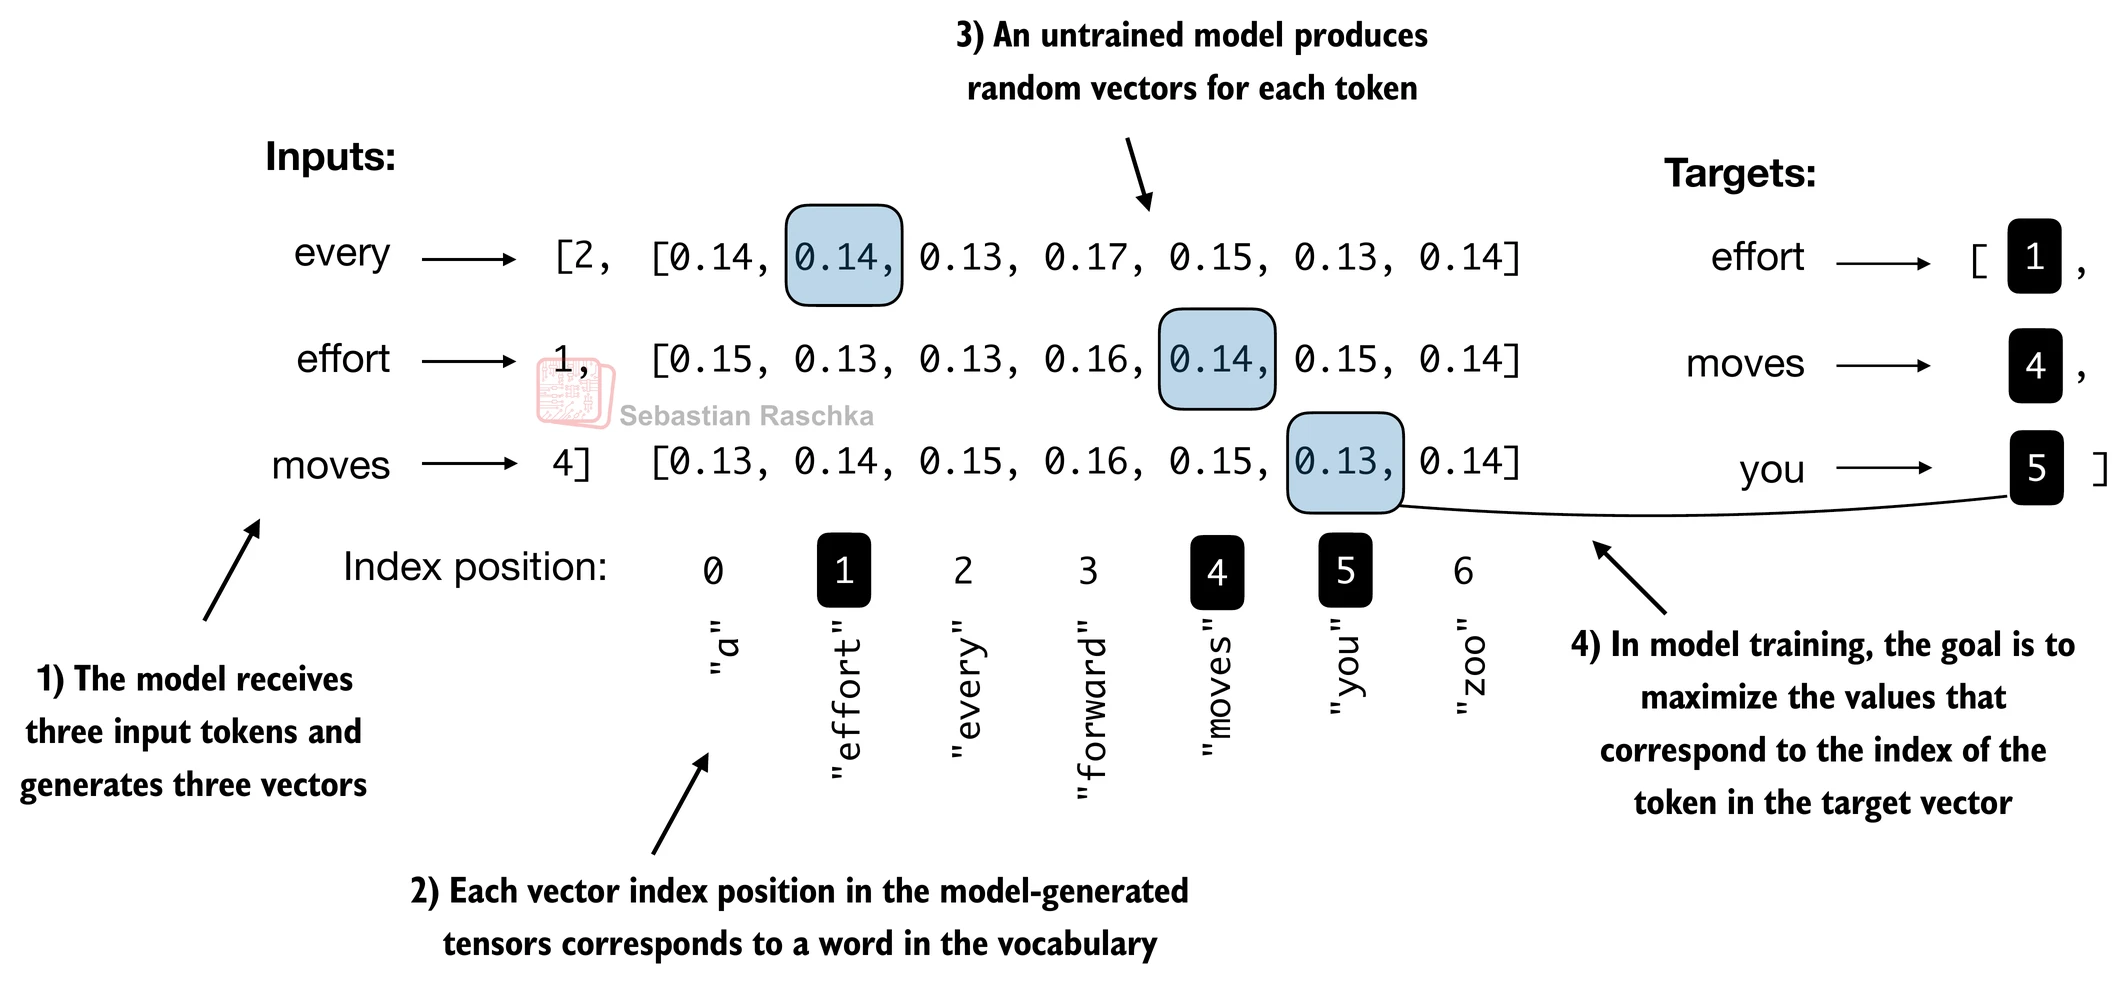

In [ ]:
#finding the intial probabilities of the target tokens from the model

text_idx = 0
#look at first batch(0), for the 3 tokens in the seq(0,1,2) and the target token ids for the first batch (targets[0])
target_probas_1 = probas[text_idx, [0,1,2], targets[text_idx]] 
print("text1: ", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0,1,2], targets[text_idx]]
print("text2: ", target_probas_2)


text1:  tensor([7.4514e-05, 3.1054e-05, 1.1567e-05])
text2:  tensor([1.0343e-05, 5.6737e-05, 4.7620e-06])


To maximize those value we need a loss function so during backpropagation the model know how to adjust its weights 

In [11]:
#we concatenate the target probabilites for both batches to have overall loss for entire batch 
#log the loss 
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2), dim=0))
print("Log probas: ", log_probas)

Log probas:  tensor([ -9.5045, -10.3798, -11.3674, -11.4792,  -9.7771, -12.2549])


*Why log?*

taking the log transforms these tiny decimals into larger numer and more stable negative numbers 

In [ ]:
#combine log probas into a single scores 

avg_log_probas = torch.mean(log_probas)
print("Average log probas: ", avg_log_probas)

#this is the cross entropy loss
neg_avg_log_probas = -avg_log_probas
print("Negative average log probas (loss): ", neg_avg_log_probas)

Average log probas:  tensor(-10.7938)
Negative average log probas (loss):  tensor(10.7938)


Currently 10.7938 we want this to be as close to 0. We need to bring it down! 

#### using cross entropy pytorch func

In [14]:
print("logits shape: ", logits.shape) # (batch_size, seq_length, vocab_size)
print("targets shape: ", targets.shape) # (batch_size, seq_length)

logits shape:  torch.Size([2, 3, 50257])
targets shape:  torch.Size([2, 3])


In [15]:
logits_flat = logits.flatten(0,1) # (batch_size * seq_length, vocab_size)
targets_flat = targets.flatten(0,1) # (batch_size * seq_length)

print("logits_flat shape: ", logits_flat.shape) # (batch_size * seq_length, vocab_size)
print("targets_flat shape: ", targets_flat.shape) # (batch_size * seq_length)

logits_flat shape:  torch.Size([6, 50257])
targets_flat shape:  torch.Size([6])


In [16]:
#unlike before needing to calc softmax first we can directly use pytorch func

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print("Cross entropy loss: ", loss)

Cross entropy loss:  tensor(10.7938)


#### Calculating the training and validation set losses
While we just did 1 batch with 2 small text snippets. We need a uatomated way to loop through an entire dataset nad compute loss for every batch and average them togther

In [17]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as f:
    text_data = f.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Total characters in text: ", total_characters)
print("Total tokens in text: ", total_tokens)

Total characters in text:  20479
Total tokens in text:  5145


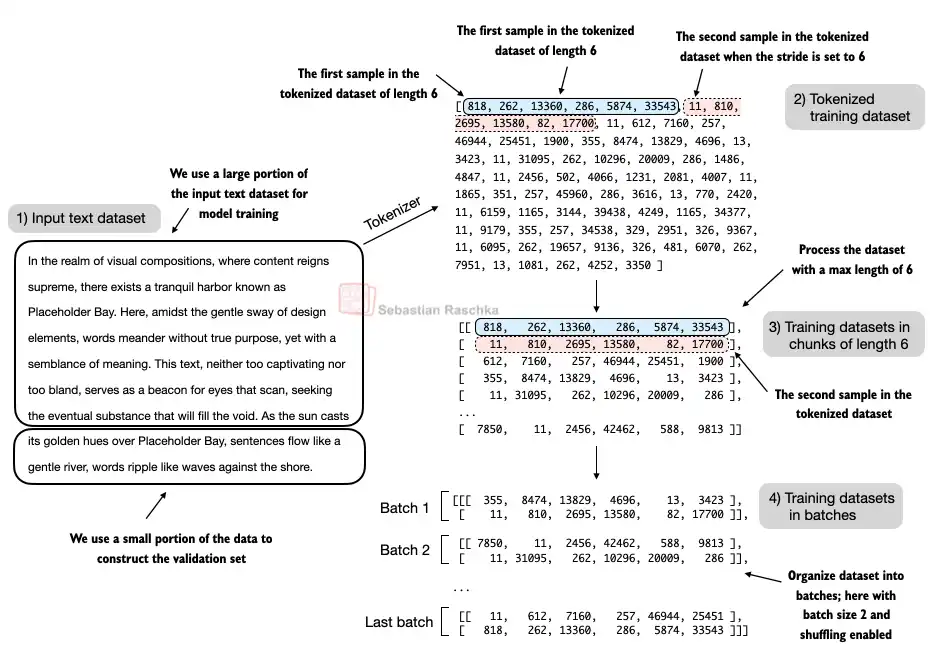
note the data is split using a 90% for training and 10% eval

In [20]:
train_ratio = 0.9 
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx] #everything up to split idx 
val_data = text_data[split_idx:] #everything after split idx

In [21]:
#same code from ch 2 REVIEW

from torch.utils.data import Dataset, DataLoader

#custom dataset for input-target pairs 
class GPTDatasetV1(Dataset):
    
    def __init__(self,txt,tokenizer,max_length, stride):
        self.input_ids = [] #hold all input ids
        self.target_ids = [] #hold all corresponding target target ids (word after the input)

        token_ids = tokenizer.encode(txt) #encoding the text into token ids 

        #sliding window to get input-target pairs
        for i in range(0,len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i+max_length] #input from i -> i + max length
            target_chunk = token_ids[i+1: i+max_length+1] #target shifted by 1 spot

            #append the input and target chunks as Tensors to be used in the dataloader
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]
    

def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    #intialize Byte Pair encoding tokenizer 
    tokenizer = tiktoken.get_encoding("gpt2")
    
    #create dataset(input-target paits) with txt 
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    #use dataloader to create batches of data (refer to appendix but high-level-> batches allow parallel processing and efficient training)
    dataloader = DataLoader(
        dataset, 
        batch_size = batch_size, #num of samples(input-target pairs) in each batch
        shuffle = shuffle, 
        drop_last = drop_last, # if smaller than batch size, drop the last batch
        num_workers = num_workers
    )
    return dataloader 

In [23]:
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size = 2,
    max_length = GPT_CONFIG_124M['context_length'],
    stride=GPT_CONFIG_124M['context_length'],
    drop_last = True,
    shuffle = True,
    num_workers = 0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size = 2,
    max_length = GPT_CONFIG_124M['context_length'],
    stride=GPT_CONFIG_124M['context_length'],
    drop_last = False,
    shuffle = False,
    num_workers = 0
)

print("Train Loader: ")
for x,y in train_loader:
    print(x.shape, y.shape) # (batch_size, seq_length) for both input and target

print ("\nValidation Loader: ")
for x,y in val_loader:
    print(x.shape, y.shape) # (batch_size, seq_length) for both input and target

Train Loader: 
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation Loader: 
torch.Size([2, 256]) torch.Size([2, 256])


9 training distinct batches while 1 validation. 
each batch has 2 samples(6 words), 256 tokens each

(x -> input, y -> target(shifted by 1 token))

In [26]:
from Pretraining import calc_loss_loader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model.to(device)

with torch.no_grad(): # no need for grad not training rn 
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Initial Train Loss: ", train_loss)
print("Initial Validation Loss: ", val_loss)


Initial Train Loss:  10.987384796142578
Initial Validation Loss:  10.980905532836914


Loss values are high as not trained. 

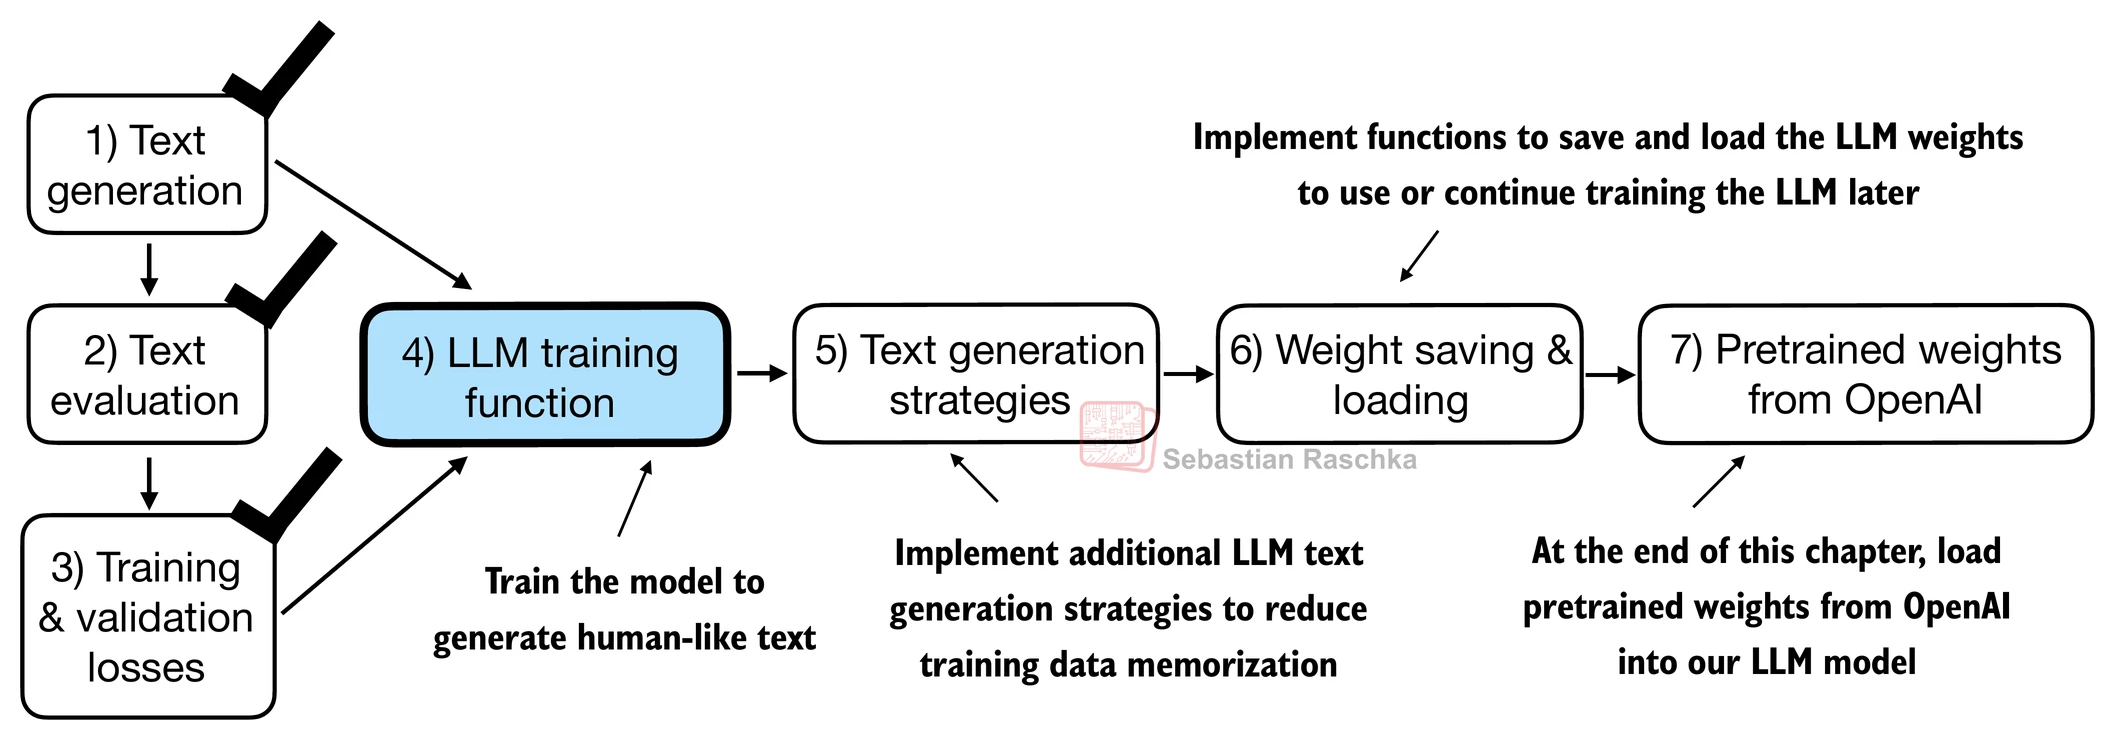

## **Training an LLM**

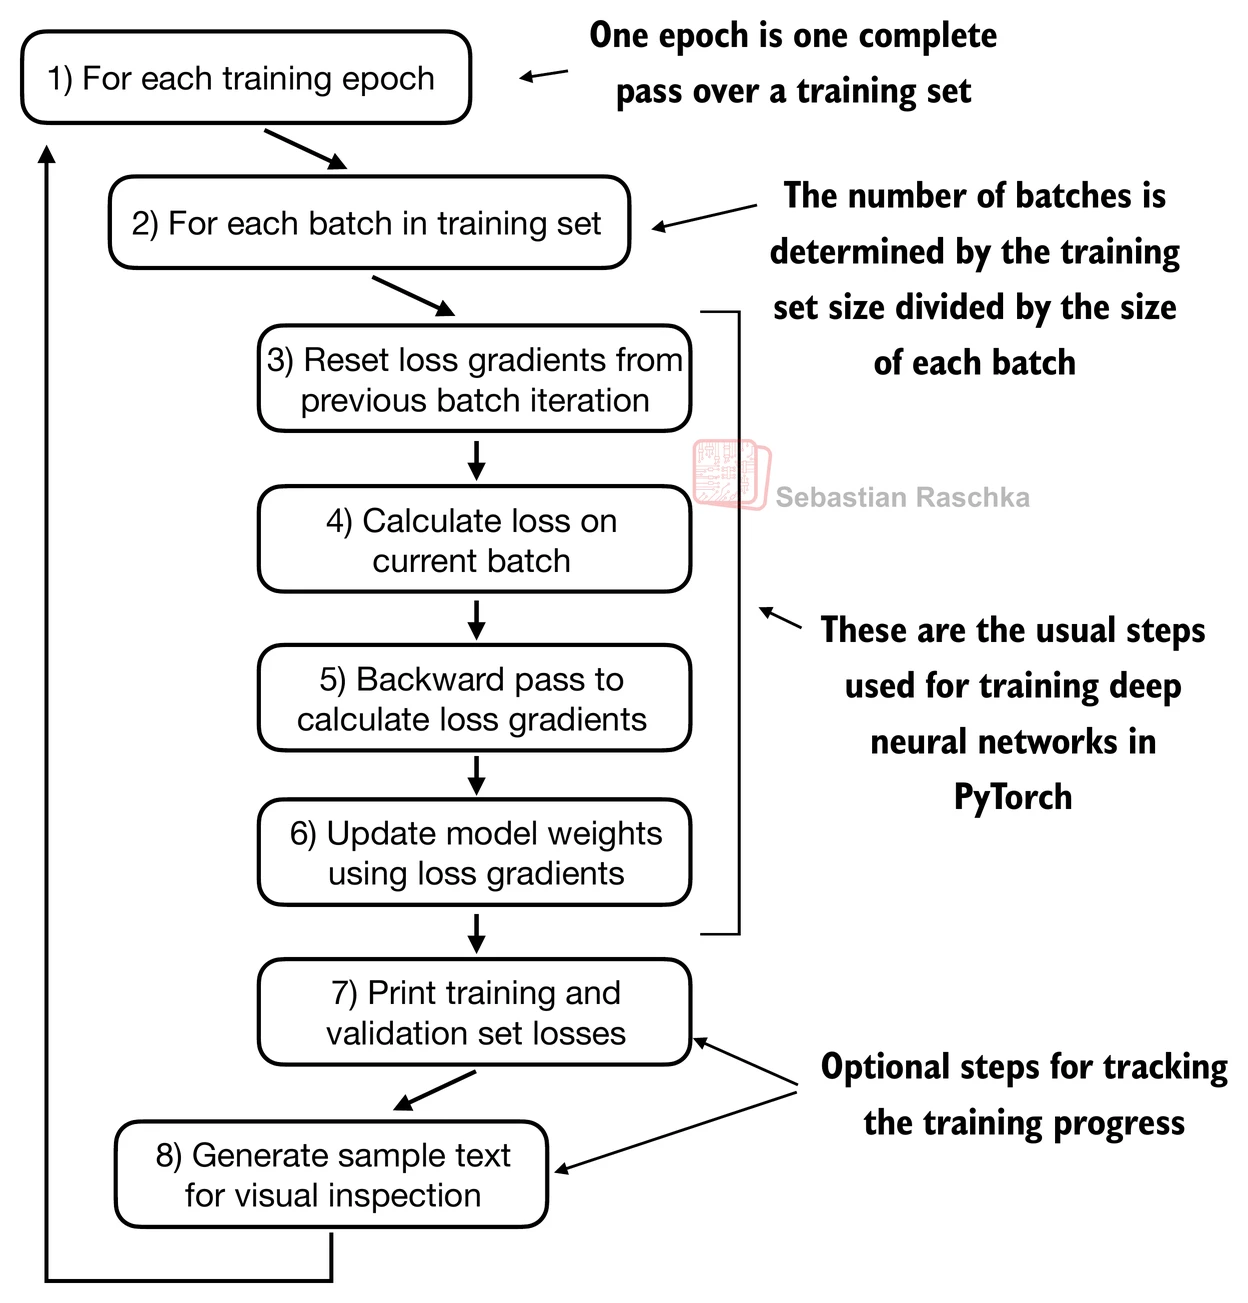